# ML-06 — Signal Audit: Do the Flags Hold?

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [2]:
%pip -q install duckdb fsspec huggingface_hub

In [3]:
import duckdb
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

con = duckdb.connect()

con.execute(
    f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

REL = "read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet')"

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

In [6]:
dist_df = con.sql(f"""
SELECT
    gsc_impressions,
    gsc_clicks,
    gsc_avg_position
FROM {REL}
WHERE gsc_data_available = TRUE
""").df()

dist_df.describe()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,gsc_impressions,gsc_clicks,gsc_avg_position
count,3.611061e+06,3.611061e+06,3.611061e+06
mean,7.772164e+01,2.275874e-01,1.582665e+01
std,2.498747e+02,1.277267e+00,1.985603e+01
min,1.000000e+00,0.000000e+00,0.000000e+00
25%,4.000000e+00,0.000000e+00,3.742120e+00
50%,1.600000e+01,0.000000e+00,7.500000e+00
75%,6.200000e+01,0.000000e+00,2.020000e+01
max,4.008400e+04,2.740000e+02,4.980000e+02


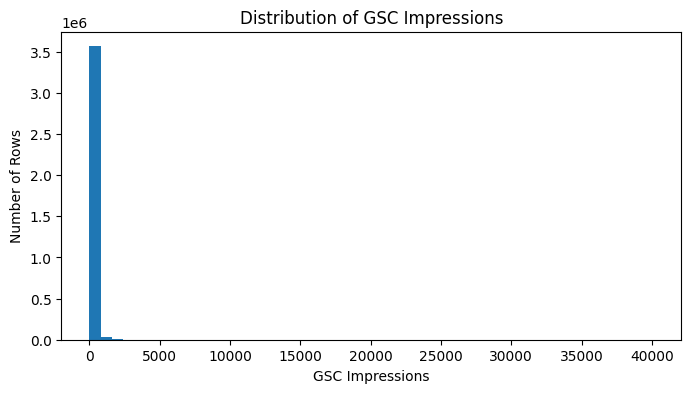

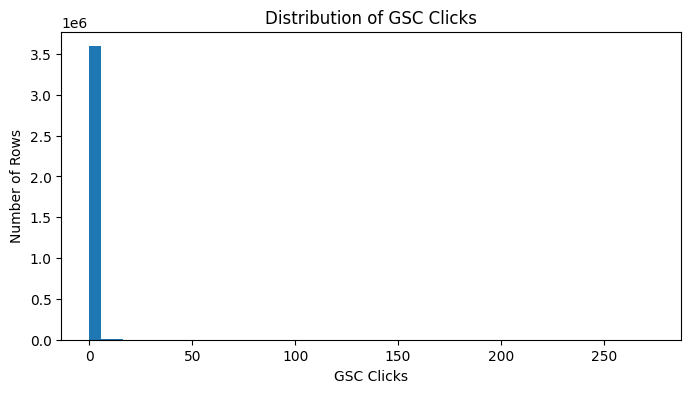

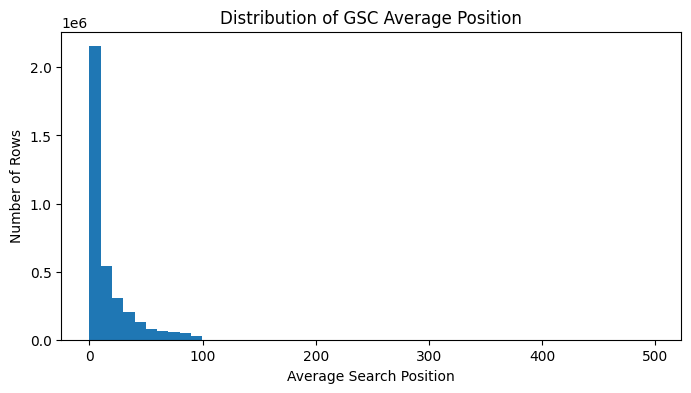

In [7]:
import matplotlib.pyplot as plt

# GSC Impressions
plt.figure(figsize=(8, 4))
plt.hist(dist_df["gsc_impressions"], bins=50)
plt.title("Distribution of GSC Impressions")
plt.xlabel("GSC Impressions")
plt.ylabel("Number of Rows")
plt.show()

# GSC Clicks
plt.figure(figsize=(8, 4))
plt.hist(dist_df["gsc_clicks"], bins=50)
plt.title("Distribution of GSC Clicks")
plt.xlabel("GSC Clicks")
plt.ylabel("Number of Rows")
plt.show()

# Average Search Position
plt.figure(figsize=(8, 4))
plt.hist(dist_df["gsc_avg_position"], bins=50)
plt.title("Distribution of GSC Average Position")
plt.xlabel("Average Search Position")
plt.ylabel("Number of Rows")
plt.show()

### Distribution observations

The distributions of GSC impressions, GSC clicks, and average search position are uneven. Most observations are concentrated at lower values, while a smaller number of observations have much larger values. This indicates that the search signals have heavy-tailed distributions, so extreme values should be considered when interpreting the results.

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [8]:
signal1 = con.sql(f"""
SELECT
    CASE
        WHEN gsc_impressions = 0 THEN 'No Impressions'
        WHEN gsc_impressions < 100 THEN 'Low'
        WHEN gsc_impressions < 1000 THEN 'Medium'
        ELSE 'High'
    END AS impressions_bucket,
    COUNT(*) AS n,
    ROUND(AVG(gsc_clicks), 2) AS avg_clicks,
    ROUND(AVG(gsc_avg_position), 2) AS avg_position
FROM {REL}
WHERE gsc_data_available = TRUE
GROUP BY 1
ORDER BY
    CASE impressions_bucket
        WHEN 'No Impressions' THEN 1
        WHEN 'Low' THEN 2
        WHEN 'Medium' THEN 3
        WHEN 'High' THEN 4
    END
""").df()

signal1

,impressions_bucket,n,avg_clicks,avg_position
0,Low,2972453,0.06,16.85
1,Medium,606189,0.80,11.02
2,High,32419,5.07,11.89


### Signal Test #1 — Impressions

Verdict: CONFIRMED

The results show a clear directional relationship between impressions and clicks.
Content with higher impressions receives more clicks on average.
Therefore, impressions appear to be a useful signal for distinguishing content performance.

In [9]:
signal2 = con.sql(f"""
SELECT
    CASE
        WHEN gsc_avg_position <= 5 THEN 'Top 5'
        WHEN gsc_avg_position <= 10 THEN 'Top 10'
        WHEN gsc_avg_position <= 20 THEN 'Top 20'
        ELSE 'Beyond 20'
    END AS position_bucket,
    COUNT(*) AS n,
    ROUND(AVG(gsc_clicks), 2) AS avg_clicks,
    ROUND(AVG(gsc_impressions), 2) AS avg_impressions
FROM {REL}
WHERE gsc_avg_position IS NOT NULL
GROUP BY 1
ORDER BY
    CASE position_bucket
        WHEN 'Top 5' THEN 1
        WHEN 'Top 10' THEN 2
        WHEN 'Top 20' THEN 3
        ELSE 4
    END
""").df()

signal2

,position_bucket,n,avg_clicks,avg_impressions
0,Top 5,1263125,0.35,96.51
1,Top 10,920359,0.22,76.01
2,Top 20,519223,0.18,56.60
3,Beyond 20,908354,0.09,65.41


In [ ]:
### Signal Test #2 — Search Position

Verdict: CONFIRMED

The results show that content in better search positions generally receives more clicks.
The Top 5 group has the highest average clicks, while content beyond position 20 has the lowest.
Therefore, search position is a useful directional signal for identifying content performance archetypes.

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.